In [59]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd
import warnings
warnings.filterwarnings('ignore') 

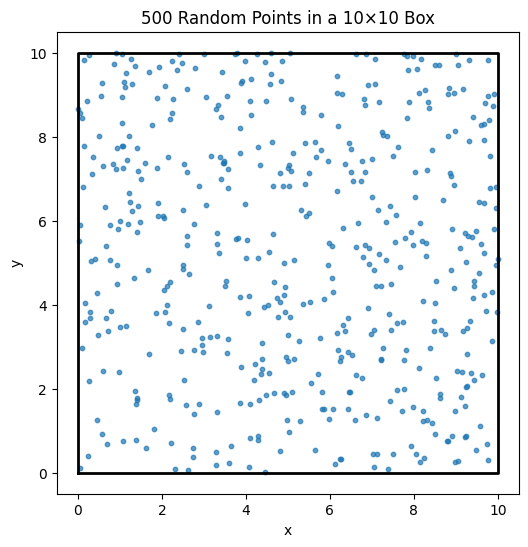

In [ ]:
box_size = 10
n_points = 500

# Random points uniformly distributed in the box
x = np.random.uniform(0, box_size, n_points)
y = np.random.uniform(0, box_size, n_points)

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(x, y, s=10, alpha=0.7)

#  box edges
box_x = [0, box_size, box_size, 0, 0]
box_y = [0, 0, box_size, box_size, 0]
ax.plot(box_x, box_y, 'k-', linewidth=2)

ax.set_xlim(-0.5, box_size + 0.5)
ax.set_ylim(-0.5, box_size + 0.5)
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'{n_points} Random Points in a {box_size}×{box_size} Box')

plt.show()

1.81796464295501 1.8132253632186148
0.13035080359207285 0.14779175755815732
0.07812764438803521 4.936049245649812


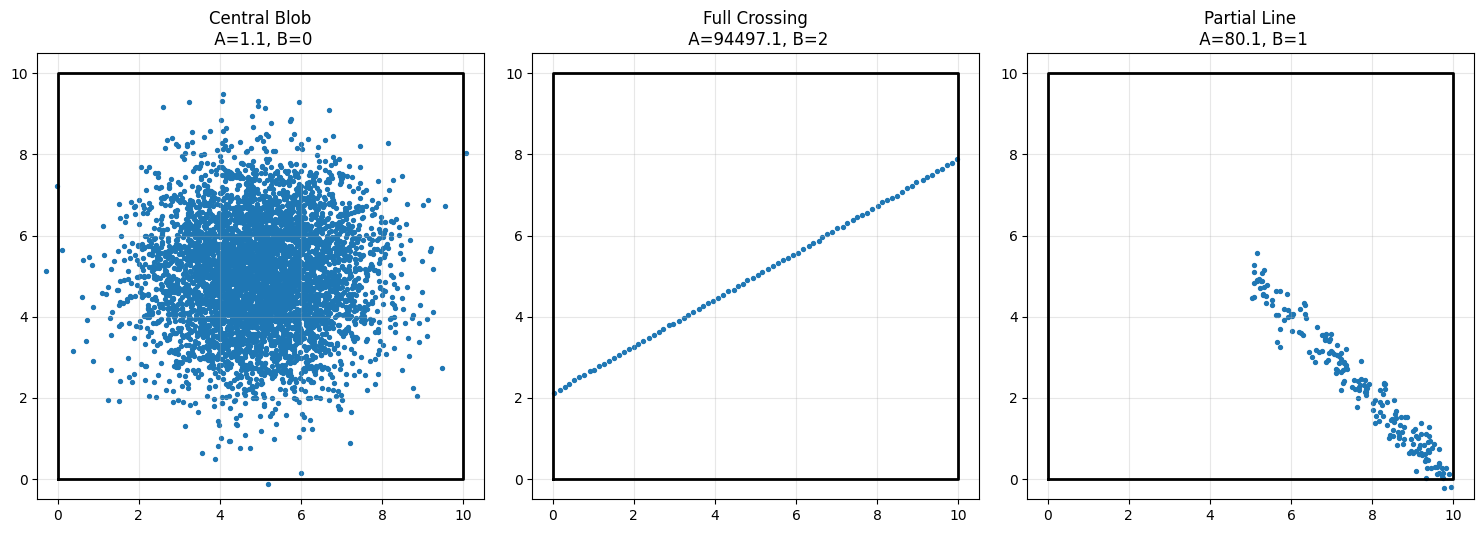


--- Scores ---
Central blob     :  anisotropy=1.06, boundary=0
Full crossing    :  anisotropy=94497.11, boundary=2
Partial line     :  anisotropy=80.08, boundary=1


In [68]:

np.random.seed(42)

box_size = 10
center = np.array([5, 5])

def score_track(x, y, box_size=10):
    pts = np.column_stack([x, y])

    # centroid
    mu = pts.mean(axis=0)

    # covariance (PCA)
    C = np.cov(pts.T)
    vals, vecs = np.linalg.eigh(C)

    # sort eigenvalues descending
    idx = np.argsort(vals)[::-1]
    vals = vals[idx]
    vecs = vecs[:, idx]

    # anisotropy (line-likeness)
    A = vals[0] / (vals[1] + 1e-12)

    # project onto principal axis
    u = vecs[:, 0]
    s = (pts - mu) @ u

    s01, s99 = np.percentile(s, [1,99])
    
    # endpoints in original space
    #p_min = mu + s.min() * u
    #p_max = mu + s.max() * u
    p_min = mu + s01*u
    p_max = mu + s99*u

    def wall_dist(p):
        x, y = p
        return min(x, box_size - x, y, box_size - y)

    d1 = wall_dist(p_min)
    d2 = wall_dist(p_max)
    print(d1,d2)

    # boundary contact score
    tau = 0.5
    B = int(d1 < tau) + int(d2 < tau)

    return A, B



fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Scenario 1: Central blob 
n1 = 5000
theta = np.pi / 4
length = 1.0

t = np.random.uniform(-length/2, length/2, n1)

x1 = center[0] + t*np.cos(theta) + np.random.normal(0, 1.35, n1)
y1 = center[1] + t*np.sin(theta) + np.random.normal(0, 1.35, n1)

A1, B1 = score_track(x1, y1, box_size)

axes[0].scatter(x1, y1, s=8)
axes[0].set_title(f"Central Blob\n A={A1:.1f}, B={B1}")


# Scenario 2: Full crossing line
n2 = 100
theta = np.pi / 6

t = np.linspace(-7, 7, n2)

x2 = center[0] + t*np.cos(theta) + np.random.normal(0, 0.01, n2)
y2 = center[1] + t*np.sin(theta) + np.random.normal(0, 0.01, n2)

mask = (x2 >= 0) & (x2 <= box_size) & (y2 >= 0) & (y2 <= box_size)

A2, B2 = score_track(x2[mask], y2[mask], box_size)

axes[1].scatter(x2[mask], y2[mask], s=8)
axes[1].set_title(f"Full Crossing\n A={A2:.1f}, B={B2}")


# Scenario 3: Partial line
n3 = 200
theta = -np.pi / 4

t = np.random.uniform(0, 7, n3)

x3 = center[0] + t*np.cos(theta) + np.random.normal(0, 0.01, n3)
y3 = center[1] + t*np.sin(theta) + np.random.normal(0, 0.3, n3) 

A3, B3 = score_track(x3, y3, box_size)

axes[2].scatter(x3, y3, s=8)
axes[2].set_title(f"Partial Line\n A={A3:.1f}, B={B3}")


#PLOT 
box_x = [0, box_size, box_size, 0, 0]
box_y = [0, 0, box_size, box_size, 0]

for ax in axes:
    ax.plot(box_x, box_y, 'k-', lw=2)
    ax.set_xlim(-0.5, box_size + 0.5)
    ax.set_ylim(-0.5, box_size + 0.5)
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


print("\n--- Scores ---")
print(f"Central blob     :  anisotropy={A1:.2f}, boundary={B1}")
print(f"Full crossing    :  anisotropy={A2:.2f}, boundary={B2}")
print(f"Partial line     :  anisotropy={A3:.2f}, boundary={B3}")

In [62]:
tps= pd.read_pickle("./trig_data/cosmics/cosmic_tps_13k_view2_1.pkl")

nutps = pd.read_pickle("./../fd-hd-benchmark-trigger/trigger_data/beam_chunks/nue_TPs_cbgd_12.pkl")
 

In [63]:
tps

,event,run_x,subrun_x,version,flag,detid,channel,samples_over_threshold,time_start,samples_to_peak,...,event_uid,original_event,apa_id,rop,bin,dbscan_label,window_start,run_y,subrun_y,TA_id
0,249108246977,12737,58,2,0,3,30481,24,4145.0,14,...,249108246977,2,11,3,4,-1,4000,12737,58,1384
1,249108246977,12737,58,2,0,3,30480,29,4147.0,17,...,249108246977,2,11,3,4,-1,4000,12737,58,1384
2,249108246977,12737,58,2,0,3,30479,31,4151.0,17,...,249108246977,2,11,3,4,-1,4000,12737,58,1384
3,249108246977,12737,58,2,0,3,30478,35,4155.0,16,...,249108246977,2,11,3,4,-1,4000,12737,58,1384
4,249108246977,12737,58,2,0,3,30477,34,4159.0,15,...,249108246977,2,11,3,4,-1,4000,12737,58,1384
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2615172,7030862131649,12737,1637,2,0,3,10120,45,1429.0,23,...,7030862131649,10,3,3,1,-1,1000,12737,1637,26866
2615173,7030862131649,12737,1637,2,0,3,10121,45,1405.0,18,...,7030862131649,10,3,3,1,-1,1000,12737,1637,26866
2615174,7030862131649,12737,1637,2,0,3,10122,46,1378.0,19,...,7030862131649,10,3,3,1,-1,1000,12737,1637,26866
2615175,7030862131649,12737,1637,2,0,3,10124,43,1330.0,17,...,7030862131649,10,3,3,1,-1,1000,12737,1637,26866


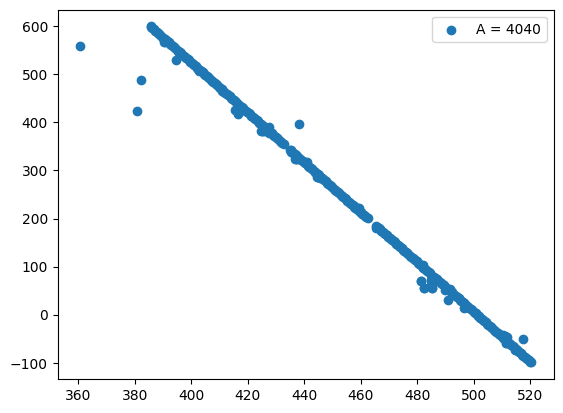

In [64]:

def get_anisotropy(df):
    df = df[df.bt_edep>0]
    x = df.bt_z
    y = df.bt_y
        
    pts = np.column_stack([x, y])

    # centroid
    mu = pts.mean(axis=0)

    # covariance (PCA)
    C = np.cov(pts.T)
    vals, vecs = np.linalg.eigh(C)

    # sort eigenvalues descending
    idx = np.argsort(vals)[::-1]
    vals = vals[idx]
    vecs = vecs[:, idx]

    # anisotropy (line-likeness)
    A = vals[0] / (vals[1] + 1e-12)

    return A



x= tps[tps.event==7030862131649]

plt.scatter(x.bt_z, x.bt_y, label = f'A = {int(get_anisotropy(x))}')
plt.legend()

In [65]:
cosmic_anisotropy_scores = tps.groupby("event_uid").apply(get_anisotropy)
beam_anisotropy_scores = nutps.groupby("event").apply(get_anisotropy)



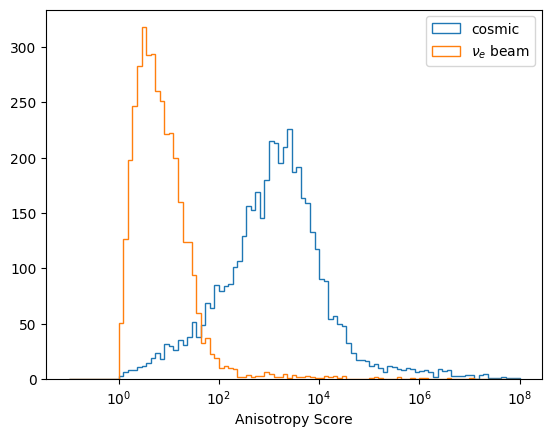

In [66]:
bins = np.logspace(-1,8, 100) 
plt.hist(cosmic_anisotropy_scores,bins=bins, histtype='step', label = 'cosmic' )
plt.hist(beam_anisotropy_scores, bins =bins, histtype='step' , label = r'$\nu_e$ beam')
plt.legend()
plt.xscale('log')
plt.xlabel("Anisotropy Score")
plt.show()

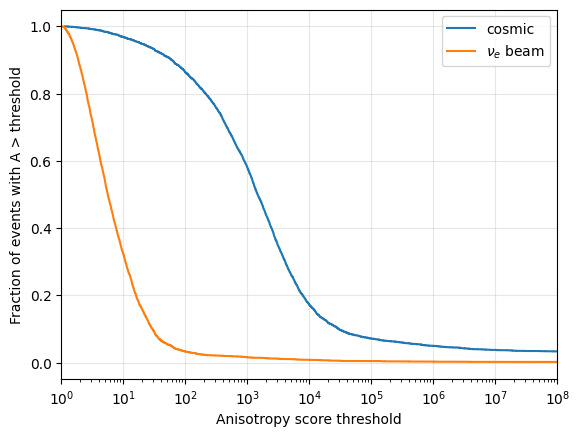

In [67]:
bins = np.logspace(-1, 8, 100)

for scores, label in [
    (cosmic_anisotropy_scores, "cosmic"),
    (beam_anisotropy_scores, r"$\nu_e$ beam")
]:
    scores = np.sort(scores)
    frac = 1 - np.arange(len(scores)) / len(scores)
    plt.step(scores, frac, where="post", label=label)

plt.xscale("log")
plt.xlabel("Anisotropy score threshold")
plt.ylabel("Fraction of events with A > threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(1,1e8)
plt.show()